In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

from A_template import  scale_array, inverse_scale_array,  process_predictions, compute_metrics, compute_error, make_windows_autoregressive

In [2]:
data_training= pd.read_excel('D:\\KULIAH S2\\Komputasi Lanjut\\TIMESERIES_CODE\\ANN\\bebanLR5_weekday_training.xlsx', index_col=0)
data_training= data_training[['Beban']].copy()
data_validation= pd.read_excel('D:\\KULIAH S2\\Komputasi Lanjut\\TIMESERIES_CODE\\ANN\\bebanLR5_weekday_validation.xlsx', index_col=0)
data_validation= data_validation[['Beban']].copy()



In [3]:
df1_training  = data_training.copy()
beban_scaled, beban_min, beban_max  =scale_array(df1_training['Beban'].values)
df1_training['Beban']   =   beban_scaled


input_make_windows      =   df1_training.to_numpy()
output_make_windows     =   df1_training['Beban'].to_numpy()

df_1_validation =   data_validation.copy()
beban_scaled_validation, _, _ = scale_array(df_1_validation['Beban'].values)
df_1_validation['Beban']    =   beban_scaled_validation


input_make_windows_validation   = df_1_validation.to_numpy()
output_make_windows_validation  = df_1_validation['Beban'].to_numpy()


In [4]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import time

def tensorflow_dense(X_train_scaled, Y_train_scaled, X_validation_scaled, Y_validation_scaled, 
                       learning_rate, target_MAE, jumlah_epochs, jumlah_sampel_batch,
                       jumlah_epoch_terbelakang, save_best_model_path, validation_data=False, load_model=None):
    global model

    class MAEStopCallback(tf.keras.callbacks.Callback):
        def __init__(self, threshold):
            super(MAEStopCallback, self).__init__()
            self.threshold = threshold

        def on_epoch_end(self, epoch, logs=None):
            if logs['mae'] < self.threshold:
                print(f"\nMAE reached below {self.threshold}. Stopping training.")
                self.model.stop_training = True

    # Mendapatkan dimensi input
    input_width = X_train_scaled.shape[1]   #  48 timesteps
    num_features = X_train_scaled.shape[2]    #11 fitur per timestep
    output_width = Y_train_scaled.shape[1]  # 48 timesteps

    model = tf.keras.models.Sequential()
    if load_model is None:
        model.add(tf.keras.layers.Input(shape=(input_width, num_features)))
        model.add(tf.keras.layers.Flatten())  # Mengubah bentuk dari (timestep, num_features) menjadi (timestep*num_features,)

        model.add(tf.keras.layers.Dense(128, activation='tanh'))

        # Output layer
        model.add(tf.keras.layers.Dense(1, activation='linear'))  # Output prediksi untuk timestep ke-49


    else:
        model = tf.keras.models.load_model(load_model)
    
    #model.summary()
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mse', 'mae', tf.keras.metrics.MeanAbsolutePercentageError(name='mape')])
    mae_stop_callback = MAEStopCallback(threshold=target_MAE)

    checkpoint_callback = ModelCheckpoint(
        save_best_model_path,
        monitor='val_mse',
        mode='min',
        save_best_only=True,
        verbose=False
    )

    early_stopping_callback = EarlyStopping(
        monitor='val_mse',
        mode='min',
        patience=jumlah_epoch_terbelakang,
        restore_best_weights=True,
        verbose=False
    )

    time_start = time.time()
    if validation_data:
        model.fit(X_train_scaled, Y_train_scaled, epochs=jumlah_epochs, batch_size=jumlah_sampel_batch,  
                  callbacks=[mae_stop_callback, checkpoint_callback, early_stopping_callback],
                  validation_data=(X_validation_scaled, Y_validation_scaled), validation_batch_size=jumlah_sampel_batch,
                  verbose=False)
    else:
        model.fit(X_train_scaled, Y_train_scaled, epochs=jumlah_epochs, batch_size=jumlah_sampel_batch, 
                  callbacks=[mae_stop_callback, checkpoint_callback, early_stopping_callback],
                  verbose=False)
    
    print("Time computation seconds: ", time.time() - time_start)
    
    loss, MSE, MAE, MAPE = model.evaluate(X_train_scaled, Y_train_scaled)
    print("Loss:", loss, "MSE:", MSE, "MAE:", MAE, "MAPE:", MAPE)
    
    return model, loss, MSE, MAE,  MAPE


In [5]:
import json
# Parameter windowing
models = []
metric_dict={"MSE_train":[], "MAE_train": [],  "MAPE_train": [], "MSE_val":[], "MAE_val": [],  "MAPE_val": []}
start_step=300-12
end_step=300+12
loss_val_before=1000
for step in range(start_step,1+end_step, 1):
    print("step: ", step)
    input_width = step
    label_width = 1
    shift = label_width
    total_window_size = input_width + shift
    OUT_STEPS = label_width
    # Definisikan irisan untuk input dan label
    input_slice = slice(0, input_width)
    label_start = total_window_size - label_width
    labels_slice = slice(label_start, None)
    x_train,    y_train     =  make_windows_autoregressive(input_make_windows, output_make_windows, input_width, label_width)
    x_val,  y_val                   = make_windows_autoregressive(input_make_windows_validation, output_make_windows_validation, input_width, label_width)
    print(x_train.shape, y_train.shape, x_val.shape, y_val.shape)

    model, loss, MSE, MAE, MAPE= tensorflow_dense(x_train, y_train, x_val, y_val, learning_rate=0.0001, target_MAE=0.001,  jumlah_epochs=200, jumlah_sampel_batch=128, 
                                                    jumlah_epoch_terbelakang=10,  save_best_model_path = "dummy_model_3.h5", 
                                                    validation_data=True, load_model=None)
    loss_val, MSE_val, MAE_val, MAPE_val = model.evaluate(x_val, y_val)
    print("Loss_val:", loss_val, "MSE_val:", MSE_val, "MAE_val:", MAE_val, "MAPE_val:", MAPE_val)
    metric_dict["MSE_train"].append(MSE)
    metric_dict["MAE_train"].append(MAE)
    metric_dict["MAPE_train"].append(MAPE)
    metric_dict["MSE_val"].append(MSE_val)
    metric_dict["MAE_val"].append(MAE_val)
    metric_dict["MAPE_val"].append(MAPE_val)

    # Simpan json dictinary ke file
    json_file_path = f"metrics_eval_3.json"
    with open(json_file_path, 'w+') as json_file:
        json.dump(metric_dict, json_file)
    if loss_val< loss_val_before:
        loss_val_before=loss_val
        model.save("best_model_3.h5")
        print("Model saved as best_model.h5")
    print()

step:  288
(12192, 288, 1) (12192, 1) (1152, 288, 1) (1152, 1)
Time computation seconds:  17.2221999168396
381/381 [==============================] - 1s 2ms/step - loss: 8.7268e-04 - mse: 8.7268e-04 - mae: 0.0218 - mape: 49.5791
Loss: 0.0008726778905838728 MSE: 0.0008726778905838728 MAE: 0.021780695766210556 MAPE: 49.57914352416992
36/36 [==============================] - 0s 2ms/step - loss: 0.0013 - mse: 0.0013 - mae: 0.0274 - mape: 25.8305
Loss_val: 0.0013288663467392325 MSE_val: 0.0013288663467392325 MAE_val: 0.02735787071287632 MAPE_val: 25.830509185791016
Model saved as best_model.h5

step:  289
(12191, 289, 1) (12191, 1) (1151, 289, 1) (1151, 1)
Time computation seconds:  24.85532522201538
381/381 [==============================] - 1s 2ms/step - loss: 5.7405e-04 - mse: 5.7405e-04 - mae: 0.0171 - mape: 35.5589
Loss: 0.0005740477354265749 MSE: 0.0005740477354265749 MAE: 0.017109697684645653 MAPE: 35.558868408203125
36/36 [==============================] - 0s 2ms/step - loss: 0.0013

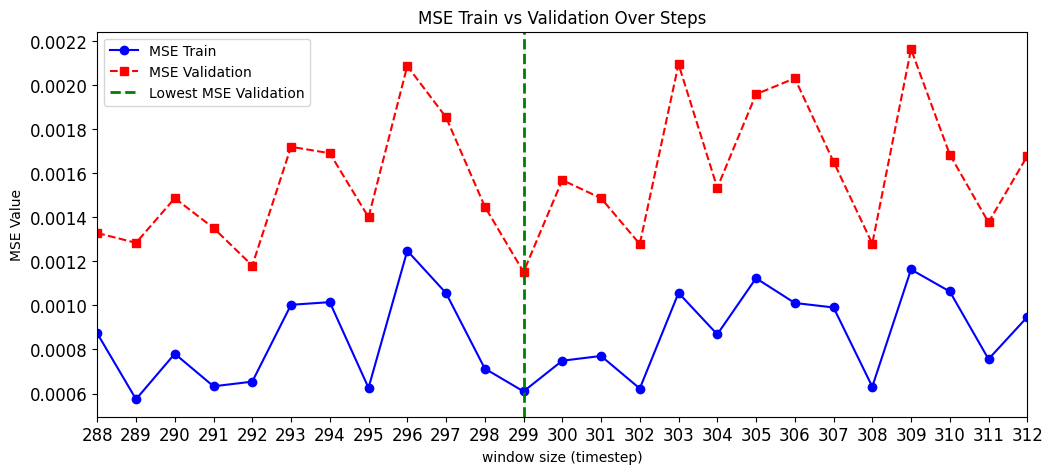

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 
# Extract data
data_train = metric_dict["MSE_train"]
data_val = metric_dict["MSE_val"]

# Generate x-values dynamically
x_values = np.arange(start_step, end_step+1, 1)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(x_values, data_train, marker='o', linestyle='-', color='b', label="MSE Train")
plt.plot(x_values, data_val, marker='s', linestyle='--', color='r', label="MSE Validation")
plt.axvline(x=(start_step+np.argmin(data_val))*1, color='g', linestyle='--', linewidth=2, label="Lowest MSE Validation")
# Labels
plt.xlabel("window size (timestep)")
plt.ylabel("MSE Value")
plt.title("MSE Train vs Validation Over Steps")
plt.xticks(np.arange(start_step,end_step+999, 1),fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(start_step, end_step)
plt.legend()

# Show plot
plt.show()


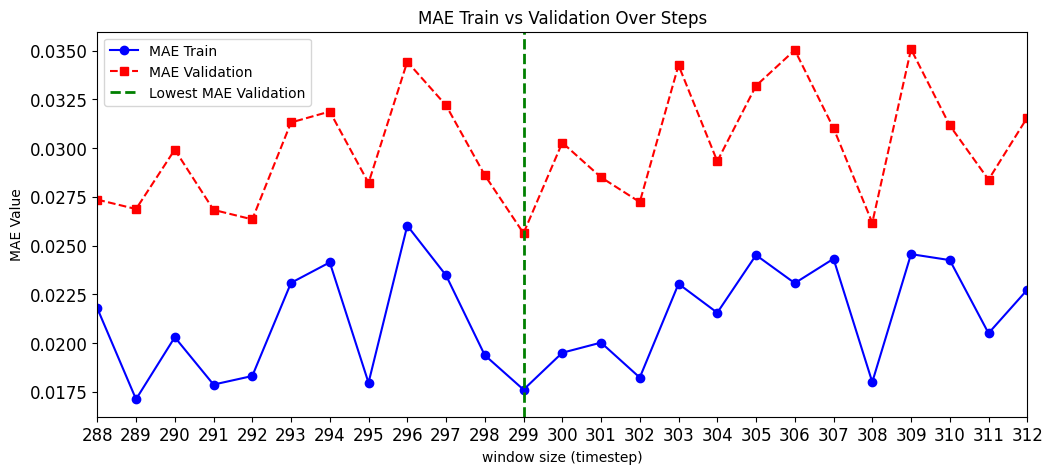

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Extract data
data_train = metric_dict["MAE_train"]
data_val = metric_dict["MAE_val"]

# Generate x-values dynamically
x_values = np.arange(start_step, end_step+1, 1)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(x_values, data_train, marker='o', linestyle='-', color='b', label="MAE Train")
plt.plot(x_values, data_val, marker='s', linestyle='--', color='r', label="MAE Validation")
plt.axvline(x=(start_step+np.argmin(data_val))*1, color='g', linestyle='--', linewidth=2, label="Lowest MAE Validation")
# Labels
plt.xlabel("window size (timestep)")
plt.ylabel("MAE Value")
plt.title("MAE Train vs Validation Over Steps")
plt.xticks(np.arange(start_step,end_step+999, 1),fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(start_step, end_step)
plt.legend()

# Show plot
plt.show()


In [8]:
np.argmin(data_val)

11